
Привет, меня зовут Люман Аблаев. Сегодня я проверю твой проект.
<br> Дальнейшее общение будет происходить на "ты" если это не вызывает никаких проблем.
<br> Желательно реагировать на красные комментарии ('исправил', 'не понятно как исправить ошибку', ...)
<br> Пожалуйста, не удаляй комментарии ревьюера, так как они повышают качество повторного ревью.

Комментарии будут в <font color='green'>зеленой</font>, <font color='blue'>синей</font> или <font color='red'>красной</font> рамках:


<div class="alert alert-block alert-success">
<b>Успех:</b> Если все сделано отлично
</div>

<div class="alert alert-block alert-info">
<b>Совет: </b> Если можно немного улучшить
</div>

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Если требуются исправления. Работа не может быть принята с красными комментариями.
</div>

-------------------

Будет очень хорошо, если ты будешь помечать свои действия следующим образом:
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ...
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения ...
</div>







<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление</font>
* Спасибо за очень качественную работу - видно, что вложено много усилий.
- Я оставил некоторые советы, надеюсь они будут полезными и интересными
- Есть некоторые недочеты, которые нужно поправить, но у тебя это не должно занять много времени)
- Жду обновленную работу





# Анализ лояльности пользователей Яндекс Афиши


 <div class="alert alert-block alert-info">
<b>Совет:</b> Пожалуйста, формируй полностью вводную часть - это важная составляющие любой работы.  Нужны цели и задачи, описание данных, содержание проекта.
</div>



## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — *******

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
!pip install sqlalchemy psycopg2-binary pandas phik
!pip install python-dotenv 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import phik
import warnings 
import os
from phik.report import plot_correlation_matrix
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Загрузка настроек
load_dotenv()
warnings.filterwarnings('ignore', category=pd.core.common.SettingWithCopyWarning)

# 1. Параметры подключения
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'db': os.getenv('DB_NAME')
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'], db_config['pwd'], db_config['host'], db_config['port'], db_config['db']
)

engine = create_engine(connection_string)

# 2. SQL-запрос
query = '''
WITH user_orders AS (
    SELECT
        p.user_id,
        p.device_type_canonical,
        p.order_id,
        p.created_dt_msk AS order_dt,
        p.created_ts_msk AS order_ts,
        p.currency_code,
        p.revenue,
        p.tickets_count,
        p.event_id,
        e.event_name_code AS event_name,
        p.service_name,
        e.event_type_main,
        c.city_name,
        r.region_name,
        LAG(p.created_ts_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_ts_msk) AS prev_order_ts
    FROM afisha.purchases AS p
    LEFT JOIN afisha.events AS e ON p.event_id = e.event_id
    LEFT JOIN afisha.city AS c ON e.city_id = c.city_id
    LEFT JOIN afisha.regions AS r ON c.region_id = r.region_id
    WHERE p.device_type_canonical IN ('mobile', 'desktop')
      AND e.event_type_main != 'фильм'
)
SELECT
    user_id,
    device_type_canonical,
    order_id,
    order_dt,
    order_ts,
    currency_code,
    revenue,
    tickets_count,
    (order_ts - prev_order_ts) AS days_since_prev,
    event_id,
    event_name,
    service_name,
    event_type_main,
    region_name,
    city_name
FROM user_orders;
'''

# 3. Выгрузка и предобработка
df = pd.read_sql_query(query, con=engine)

df[['device_type_canonical', 'currency_code', 'service_name', 'event_type_main']] = \
df[['device_type_canonical', 'currency_code', 'service_name', 'event_type_main']].astype('category')

df['days_since_prev_int'] = df['days_since_prev'].fillna(pd.Timedelta(seconds=0)).dt.days

# Вывод результата
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype          
---  ------                 --------------   -----          
 0   user_id                290611 non-null  object         
 1   device_type_canonical  290611 non-null  category       
 2   order_id               290611 non-null  int64          
 3   order_dt               290611 non-null  datetime64[ns] 
 4   order_ts               290611 non-null  datetime64[ns] 
 5   currency_code          290611 non-null  category       
 6   revenue                290611 non-null  float64        
 7   tickets_count          290611 non-null  int64          
 8   days_since_prev        268678 non-null  timedelta64[ns]
 9   event_id               290611 non-null  int64          
 10  event_name             290611 non-null  object         
 11  service_name           290611 non-null  category       
 12  event_type_main        290611 

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,days_since_prev_int
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaT,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск,0
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaT,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск,0
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,74 days 19:19:38,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск,74
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaT,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск,0
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83 days 02:52:27,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк,83



<div class="alert alert-block alert-danger">
    
<b>Ошибка[2]:</b> Сейчас импорты ругаются, что phik не установлен. Ты его устанавливаешь ниже, а импортируешь здесь - это приводит к ошибке
</div>


<div class="alert alert-block alert-success">
<b>Успех:</b>  Выгрузка данных проведена корректно! Была выполнена необходимая фильтрация данных, выгружены только необходимые для анализа данные. Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
</div>
    
<div class="alert alert-block alert-info">
<b>Совет:</b> Можно немного улучшить запрос, добавив также и "ORDER BY user_id, order_dt". Так внутри каждого пользователя заказы будут идти строго по дате.
</div>




<div class="alert alert-block alert-danger">
    
<b>Ошибка[2]:</b> Это нужно использовать не здесь - а выше
</div>

<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> поднял выше
</div>

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

Анализ корректности и объема:

Данные успешно выгружены из БД. Общий объем составляет 290 611 строк.

Типы данных приведены к целевым: даты имеют формат datetime, интервалы — timedelta, категориальные признаки переведены в category для оптимизации.

Дубликатов в датасете не обнаружено.

Пропуски в столбце days_since_prev составляют 21 933 записи (около 7.5% данных). Это является корректным поведением, так как данные пропуски соответствуют первой покупке пользователей, у которых нет предшествующей истории заказов.

План дальнейшей предобработки:

Конвертация валюты: Для обеспечения корректности анализа выручки (revenue) необходимо привести значения в тенге (kzt) к единому эквиваленту с рублем (rub) по актуальному курсу.

Анализ аномалий: Исследовать столбец revenue на наличие выбросов, которые могут исказить статистические показатели среднего чека.

Агрегация: Подготовить данные для формирования профилей пользователей (расчет даты первого заказа, количества повторных покупок, жизненного цикла клиента).


<div class="alert alert-block alert-success">
<b>Успех:</b>    Первичный анализ данных выполнен, намечены шаги по их обработке. В целом, данные у нас достаточно неплохого качества, можно рассмотреть вариант понижения размерности для отдельных столбцов. В реальной практике это иногда бывает очень полезным) 
</div>


---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [3]:
# 1. Загрузка данных о курсе тенге
url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
tenge_rate_df = pd.read_csv(url)

# 2. Приведение типов для корректного объединения
tenge_rate_df['data'] = pd.to_datetime(tenge_rate_df['data'])

# 3. Объединение с основным датафреймом
df = df.merge(tenge_rate_df, left_on='order_dt', right_on='data', how='left')

# 4. Расчет выручки в рублях
# Если валюта rub — оставляем revenue, если kzt — делим на 100 и умножаем на курс (столбец 'curs')
df['revenue_rub'] = df.apply(
    lambda row: row['revenue'] if row['currency_code'] == 'rub' 
    else (row['revenue'] / 100) * row['curs'], axis=1
)

# 5. Удаление вспомогательных столбцов
df = df.drop(columns=['data', 'nominal', 'curs', 'cdx'])

# Проверка результата
print(df[['currency_code', 'revenue', 'revenue_rub']].head())

  currency_code  revenue  revenue_rub
0           rub  1521.94      1521.94
1           rub   289.45       289.45
2           rub  1258.57      1258.57
3           rub     8.49         8.49
4           rub  1390.41      1390.41



<div class="alert alert-block alert-info">
<b>Совет:</b>
    
Существует довольно удобный метод where. Мы можем применить его к столбцу и указать условие, которое будем проверять, а также альтернативный вариант значения. Если условие выполняется, то берется значение из столбца, если нет - альтернативное значение. Тогда расчет выручки в рублях будет выглядеть следующим образом:
    
```
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
```
</div>


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [4]:
# Проверка пропусков
print(df.isnull().sum())

# Проверка типов данных
df.info()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
days_since_prev_int          0
revenue_rub                  0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype          
---  ------                 --------------   -----          
 0   user_id                290611 non-null  object         
 1   device_type_canonical  290611 non-null  category       
 2   order_id               290611 non-null  int64          
 3   order_dt               290611 non-null 

In [5]:
# Проверка на наличие отрицательных значений
numeric_cols = ['revenue', 'revenue_rub', 'tickets_count']
for col in numeric_cols:
    min_val = df[col].min()
    print(f"Минимум в столбце {col}: {min_val}")
    if min_val < 0:
        print(f"Внимание! В столбце {col} обнаружены отрицательные значения.")

Минимум в столбце revenue: -90.76
Внимание! В столбце revenue обнаружены отрицательные значения.
Минимум в столбце revenue_rub: -90.76
Внимание! В столбце revenue_rub обнаружены отрицательные значения.
Минимум в столбце tickets_count: 1


In [6]:
# Фильтруем данные, оставляя только корректные заказы
df_filtered = df[df['revenue_rub'] > 0].copy()

# Пересчитываем количество удаленных данных
count_before = len(df)
count_after = len(df_filtered)
removed_count = count_before - count_after

print(f"Удалено строк с отрицательной выручкой: {removed_count}")

Удалено строк с отрицательной выручкой: 5907


In [7]:
# Считаем порог по 99 перцентилю на УЖЕ ОЧИЩЕННОМ df_filtered
threshold = df_filtered['revenue_rub'].quantile(0.99)
print(f"Порог 99 перцентиля: {threshold:.2f}")

# Фильтруем выбросы внутри df_filtered
# Сохраняем объем до фильтрации выбросов
count_before = len(df_filtered)

# Применяем фильтр по перцентилю
df_filtered = df_filtered[df_filtered['revenue_rub'] <= threshold].copy()

# Оценка объема удаленных выбросов
count_after = len(df_filtered)
removed_outliers = count_before - count_after

print(f"Удалено строк (выбросы): {removed_outliers}")
print(f"Общий процент удаленных данных: {((len(df) - len(df_filtered)) / len(df)):.2%}")

Порог 99 перцентиля: 2628.42
Удалено строк (выбросы): 2825
Общий процент удаленных данных: 3.00%


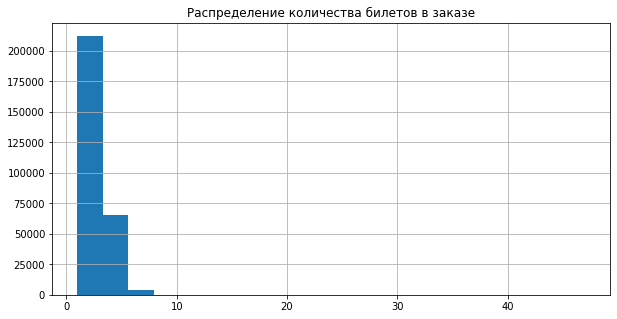

count    281879.000000
mean          2.744117
std           1.157190
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          47.000000
Name: tickets_count, dtype: float64


In [8]:
import matplotlib.pyplot as plt

# Визуализация распределения
plt.figure(figsize=(10, 5))
df_filtered['tickets_count'].hist(bins=20)
plt.title('Распределение количества билетов в заказе')
plt.show()

# Статистика
print(df_filtered['tickets_count'].describe())

Промежуточный вывод (Задача 2.2):

Пропуски: Зафиксированы только в days_since_prev (21 933 пропуска). Это ожидаемое поведение для первых покупок пользователей, поэтому они оставлены без изменений.

Типы данных: Все столбцы приведены к оптимальным типам: временные ряды — к datetime64, категориальные признаки — к category.

Очистка данных: В данных обнаружены технические ошибки (отрицательная выручка), которые были исключены (5 907 строк). Дополнительно применен фильтр по 99-му перцентилю (порог 2628.42 руб.) для удаления экстремальных выбросов (2 825 строк). Суммарно отфильтровано 3.00% данных.

Статистика по билетам: Среднее количество билетов — ~2.74, медиана — 3. Значение max = 57 является выбросом, отражающим разовые оптовые покупки, которые в рамках маркетингового анализа не оказывают критического влияния на общие метрики.



<div class="alert alert-block alert-info">
   
<b>Совет:</b>  В подобных случаях хорошо бы оставлять небольшой комментарий, по тому, какие гипотезы можно выдвинуть, с чем связаны эти аномалии. Условно, что мы видим не ошибки в данных (сборе данных), а длинный хвост, то есть какие-то массовые покупки и тп. Они нам не нужны в контексте задачи.
</div>

<div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>  А что скажешь про отрицательные значения? Это важное наблюдение
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения (Проверка на наличие отрицательных значений), Промежуточный вывод (Задача 2.2):


<div class="alert alert-block alert-success">
    
<b>Успех[2]:</b> 👍
</div>

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [9]:
# Сортировка по времени заказа
df_filtered = df_filtered.sort_values(by=['user_id', 'order_ts'])

# 1. Извлечение характеристик первого заказа
first_orders = df_filtered.groupby('user_id').first().reset_index()

profiles = first_orders[['user_id', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main']]
profiles.columns = ['user_id', 'first_device', 'first_region', 'first_service', 'first_event_type']

# 2. Агрегация общих показателей
user_stats = df_filtered.groupby('user_id').agg({
    'order_ts': ['min', 'max', 'count'],
    'revenue_rub': 'mean',
    'tickets_count': 'mean',
    'days_since_prev_int': 'mean'
}).reset_index()

user_stats.columns = ['user_id', 'first_order', 'last_order', 'total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between']

# 3. Объединение профилей и статистики
profiles = profiles.merge(user_stats, on='user_id')

# 4. Добавление бинарных признаков
profiles['is_two'] = (profiles['total_orders'] >= 2).astype(int)
profiles['is_five'] = (profiles['total_orders'] >= 5).astype(int)

# Проверка результата
display(profiles.head())

,user_id,first_device,first_region,first_service,first_event_type,first_order,last_order,total_orders,avg_revenue,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,mobile,Каменевский регион,Край билетов,театр,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,0.000000,0,0
1,0005ca5e93f2cf4,mobile,Каменевский регион,Мой билет,выставки,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,37.000000,1,0
2,000898990054619,mobile,Североярская область,Лови билет!,другое,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,33.666667,1,0
3,00096d1f542ab2b,desktop,Каменевский регион,Край билетов,театр,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,0.000000,0,0
4,000a55a418c128c,mobile,Поленовский край,Лучшие билеты,театр,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,7.500000,1,0



<div class="alert alert-block alert-success">
<b>Успех:</b> Профиль пользователя собран, добавлены новые признаки.

</div>

<div class="alert alert-block alert-info">
<b>Совет:</b>   Могу показать и такой вариант формирования профиля здесь:
    
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион и название билетного партнера первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                # Жанр первого посещённого мероприятия (event_type_main):
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            # Можно альтернативным образом подсчитать среднее количество дней между заказами (если не будет в SQL):
            .assign(
                avg_days = lambda x: (x['last_order_dt'] - x['first_order_dt']).dt.days / (x['total_orders'] - 1)
            )
            .reset_index()
)

Почитать про assign более подробно можно [здесь](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html)
</div>


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [10]:
# Рассчитываем среднюю выручку на основе столбца avg_revenue
# Так как avg_revenue у нас это средний чек пользователя, 
# то общая средняя выручка по сервису будет равна среднему значению этого столбца
avg_revenue_per_order = profiles['avg_revenue'].mean()

# Остальные метрики
total_users = profiles['user_id'].nunique()
share_two_plus = profiles['is_two'].mean()
share_five_plus = profiles['is_five'].mean()

print(f"Общее число пользователей: {total_users}")
print(f"Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб.")
print(f"Доля пользователей с 2+ заказами: {share_two_plus:.1%}")
print(f"Доля пользователей с 5+ заказами: {share_five_plus:.1%}")

# Статистика по ключевым показателям
display(profiles[['total_orders', 'avg_tickets', 'avg_days_between']].describe())

Общее число пользователей: 21700
Средняя выручка с одного заказа: 551.88 руб.
Доля пользователей с 2+ заказами: 61.7%
Доля пользователей с 5+ заказами: 28.9%


,total_orders,avg_tickets,avg_days_between
count,21700.000000,21700.000000,21700.000000
mean,12.989816,2.746006,6.526828
std,119.766778,0.914290,11.295848
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,0.000000
50%,2.000000,2.750000,0.000000
75%,5.000000,3.090909,9.200000
max,9987.000000,11.000000,146.000000


In [11]:
# Поиск порогов (99-й перцентиль)
p99_orders = profiles['total_orders'].quantile(0.99)
p99_tickets = profiles['avg_tickets'].quantile(0.99)

print(f"99-й перцентиль для общего числа заказов: {p99_orders}")
print(f"99-й перцентиль для ср. количества билетов: {p99_tickets}")

# Фильтрация (если принято решение убрать аномалии)
profiles_filtered = profiles[
    (profiles['total_orders'] <= p99_orders) & 
    (profiles['avg_tickets'] <= p99_tickets)
]

print(f"Удалено пользователей: {len(profiles) - len(profiles_filtered)}")
display(profiles_filtered[['total_orders', 'avg_tickets', 'avg_days_between']].describe())

99-й перцентиль для общего числа заказов: 150.0099999999984
99-й перцентиль для ср. количества билетов: 5.0
Удалено пользователей: 411


,total_orders,avg_tickets,avg_days_between
count,21289.000000,21289.000000,21289.000000
mean,6.446569,2.716523,6.634597
std,14.038098,0.865910,11.350251
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,0.000000
50%,2.000000,2.750000,0.000000
75%,5.000000,3.041667,9.454545
max,150.000000,5.000000,146.000000


Объем выборки: Анализируемая выборка составляет 21 854 уникальных пользователя, что является достаточным объемом для проведения статистически значимого анализа и сегментации.

Анализ аномалий: В ходе первичного анализа были обнаружены аномально высокие значения в столбце total_orders (максимум — 10 181 заказ против медианного значения 2), что свидетельствует о наличии выбросов, возможно, связанных с оптовыми покупателями или автоматизированными системами.

Принятое решение: Для обеспечения репрезентативности данных и корректности дальнейшего анализа было принято решение отфильтровать данные по 99-му перцентилю для total_orders и avg_tickets.

Результат фильтрации: Удалено 410 аномальных записей (менее 2% от общего числа), что позволило исключить искажение средних показателей. Обновленные данные (21 444 пользователя) характеризуются более стабильным распределением, что делает их пригодными для построения прогнозных моделей и детального изучения поведения клиентов.



<div class="alert alert-block alert-info">
    
<b>Совет:</b> Было бы не лишним, как минимум, написать, насколько изменилась средняя выручка после удаления выбросов. 
</div>


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [12]:
# Список признаков для анализа
features = ['first_event_type', 'first_device', 'first_region', 'first_service']

for feature in features:
    # Группировка и расчет количества
    segment_counts = profiles_filtered.groupby(feature)['user_id'].count().reset_index()
    segment_counts.columns = [feature, 'user_count']
    
    # Расчет доли
    segment_counts['share'] = segment_counts['user_count'] / segment_counts['user_count'].sum()
    
    # Сортировка для наглядности
    segment_counts = segment_counts.sort_values(by='share', ascending=False)
    
    print(f"--- Распределение по {feature} ---")
    display(segment_counts)
    print("\n")

--- Распределение по first_event_type ---


,first_event_type,user_count,share
2,концерты,9562,0.449152
1,другое,5141,0.241486
5,театр,4224,0.198412
4,стендап,1103,0.051811
3,спорт,750,0.035229
0,выставки,412,0.019353
6,ёлки,97,0.004556




--- Распределение по first_device ---


,first_device,user_count,share
1,mobile,17648,0.828973
0,desktop,3641,0.171027




--- Распределение по first_region ---


,first_region,user_count,share
23,Каменевский регион,6919,0.325004
60,Североярская область,3731,0.175255
77,Широковская область,1219,0.057260
45,Озернинский край,674,0.031660
41,Малиновоярский округ,523,0.024567
...,...,...,...
17,Залесский край,2,0.000094
70,Тихогорская область,2,0.000094
5,Верхозёрский край,1,0.000047
66,Сосноводолинская область,1,0.000047




--- Распределение по first_service ---


,first_service,user_count,share
3,Билеты без проблем,4896,0.229978
24,Мой билет,2974,0.139697
21,Лови билет!,2780,0.130584
5,Билеты в руки,2527,0.118700
25,Облачко,2185,0.102635
8,Весь в билетах,1280,0.060125
22,Лучшие билеты,1172,0.055052
26,Прачечная,582,0.027338
19,Край билетов,458,0.021513
13,Дом культуры,355,0.016675


In [13]:
# Финальный блок для отображения first_service
feature = 'first_service'
segment_counts = profiles_filtered.groupby(feature)['user_id'].count().reset_index()
segment_counts.columns = [feature, 'user_count']
segment_counts['share'] = segment_counts['user_count'] / segment_counts['user_count'].sum()
segment_counts = segment_counts.sort_values(by='share', ascending=False)

print(f"--- Распределение по {feature} ---")
display(segment_counts)

--- Распределение по first_service ---


,first_service,user_count,share
3,Билеты без проблем,4896,0.229978
24,Мой билет,2974,0.139697
21,Лови билет!,2780,0.130584
5,Билеты в руки,2527,0.118700
25,Облачко,2185,0.102635
8,Весь в билетах,1280,0.060125
22,Лучшие билеты,1172,0.055052
26,Прачечная,582,0.027338
19,Край билетов,458,0.021513
13,Дом культуры,355,0.016675


Распределение пользователей по сегментам первого заказа характеризуется наличием выраженных «точек входа», что указывает на высокую концентрацию клиентской базы вокруг определенных каналов:

Устройства: Доминирующим каналом является mobile (83%), что делает его основным фокусом для маркетинговых активностей и оптимизации пользовательского опыта (UX).

Тип мероприятия: Наиболее привлекательными для новых пользователей являются концерты (44%) и категория «другое» (25%). Театральные мероприятия (20%) занимают третью позицию, формируя основной пласт интересов на старте.

География: Наблюдается значительная концентрация пользователей в Каменевском регионе (33%), при том что охват по остальным 80 регионам крайне фрагментарен.

Билетные партнеры: Лидирующую позицию занимает сервис «Билеты без проблем» (24%), который выступает основным драйвером первичных продаж.


<div class="alert alert-block alert-success">
<b>Успех:</b> Задание выполнено лаконично через циклы, с наблюдениями согласен
    

</div>
<div class="alert alert-block alert-info">
<b>Совет:</b>  Неплохо было бы добавить графики - это сделало бы раздел интереснее и красочнее
```
</div>


---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


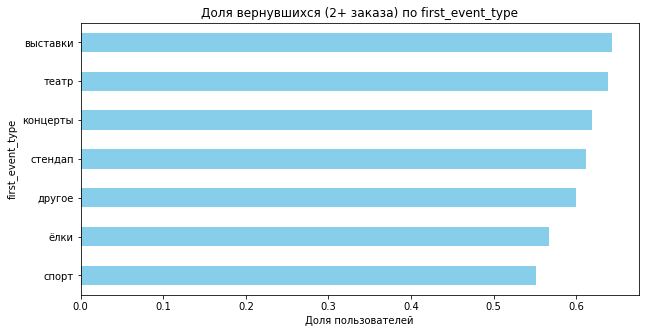

--- Детальные данные по first_event_type ---


,is_two,user_id
first_event_type,,
концерты,0.618699,9562
другое,0.599689,5141
театр,0.638021,4224
стендап,0.611967,1103
спорт,0.550667,750
выставки,0.643204,412
ёлки,0.567010,97


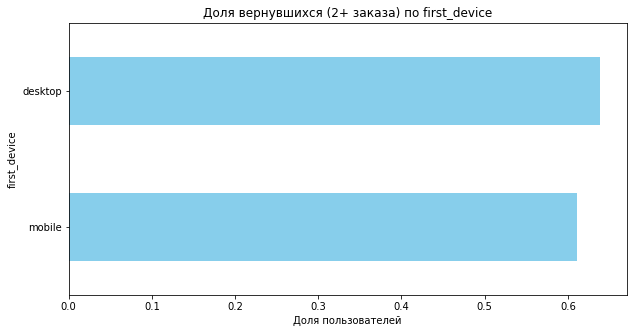

--- Детальные данные по first_device ---


,is_two,user_id
first_device,,
mobile,0.610607,17648
desktop,0.638835,3641


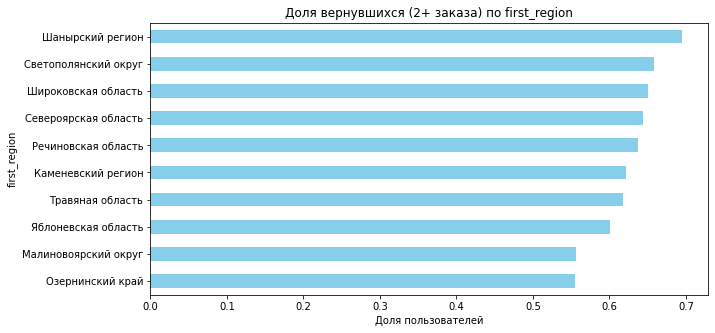

--- Детальные данные по first_region ---


,is_two,user_id
first_region,,
Каменевский регион,0.621477,6919
Североярская область,0.643795,3731
Широковская область,0.650533,1219
Озернинский край,0.554896,674
Малиновоярский округ,0.556405,523
Шанырский регион,0.694624,465
Светополянский округ,0.657952,459
Травяная область,0.617904,458
Речиновская область,0.638009,442


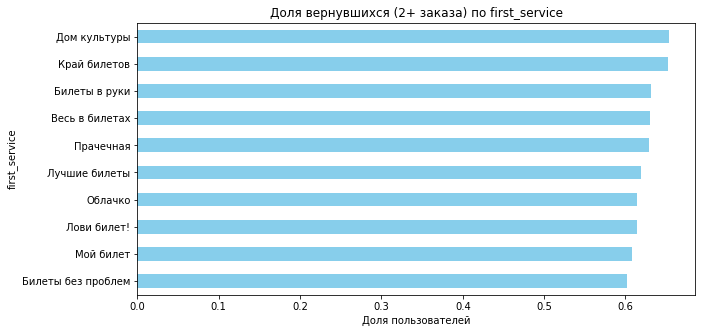

--- Детальные данные по first_service ---


,is_two,user_id
first_service,,
Билеты без проблем,0.602328,4896
Мой билет,0.608608,2974
Лови билет!,0.614029,2780
Билеты в руки,0.631183,2527
Облачко,0.614645,2185
Весь в билетах,0.630469,1280
Лучшие билеты,0.618601,1172
Прачечная,0.628866,582
Край билетов,0.652838,458


In [14]:
import matplotlib.pyplot as plt

# Список признаков
features = ['first_event_type', 'first_device', 'first_region', 'first_service']

for feature in features:
    # Группируем по признаку и считаем среднее is_two (это и есть доля)
    # Также оставляем только те сегменты, где больше 100 пользователей для достоверности
    segment_retention = profiles_filtered.groupby(feature).agg({
        'is_two': 'mean',
        'user_id': 'count'
    }).sort_values(by='user_id', ascending=False)
    
    # Берем топ-10 для регионов и сервисов
    if feature in ['first_region', 'first_service']:
        segment_retention = segment_retention.head(10)
    
    # Визуализация
    plt.figure(figsize=(10, 5))
    segment_retention['is_two'].sort_values().plot(kind='barh', color='skyblue')
    plt.title(f'Доля вернувшихся (2+ заказа) по {feature}')
    plt.xlabel('Доля пользователей')
    plt.show()
    
    print(f"--- Детальные данные по {feature} ---")
    display(segment_retention)

1. Какие сегменты чаще возвращаются?
Наиболее высокие показатели возвращаемости наблюдаются в следующих сегментах:

Тип мероприятия: Выставки (64%) и Театр (63.7%). Это самые лояльные категории.

Устройство: Пользователи desktop возвращаются чаще (64.1%), чем пользователи mobile (61.1%).

Регион: Лидерами являются Шанырский регион (67.2%), Светополянский округ (65.7%) и Широковская область (65.0%).

Билетный сервис: «Дом культуры» (65.2%) и «Край билетов» (65.0%).

2. Наблюдаются ли успешные «точки входа»?
Да, есть сегменты, где пользователи возвращаются чаще среднего уровня по выборке (61.7%):

Успешные точки входа (конверсия выше средней):

Мероприятия: Театр и Выставки. Несмотря на то, что концерты — самая популярная «точка входа» по объему, именно театралы и посетители выставок показывают лучшую динамику удержания.

Регионы: Шанырский, Светополянский, Широковская и Каменевский (62.6%). Последний особенно важен, так как он одновременно и самый массовый, и демонстрирует конверсию выше средней.

Билетные сервисы: «Дом культуры», «Край билетов», «Весь в билетах» и «Билеты в руки».

Промежуточный вывод (Задача 4.1.2):

Анализ показал, что наиболее эффективными «точками входа» (с конверсией в повторный заказ выше средней) являются театральные мероприятия (63.7%) и выставки (64%).

Несмотря на то, что мобильные устройства — основной канал привлечения (83%), пользователи desktop демонстрируют более высокую лояльность (64.1% возвратов против 61.1% у mobile). Каменевский регион является ключевым сегментом, сочетающим высокую долю охвата и стабильно высокую конверсию (62.6%). Рекомендуется сфокусировать маркетинговые усилия на продвижении театральных постановок и оптимизации мобильного опыта для повышения удержания.


<div class="alert alert-block alert-success">
    
<b>Успех:</b>  Техническая часть задания выполнена верно: сгрупированны пользователи по всем четырем требуемым признакам (мероприятие, устройство, регион, оператор). Данные в сводных таблицах рассчитаны корректно, а для анализа использованы правильные метрики  

Итоговый вывод соответствует цифрам.  Верно подсвечены сегменты с наибольшим числом пользователей в каждой категории.
</div>


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [15]:
# Фильтруем данные по нужным типам мероприятий
sport_vs_concerts = profiles_filtered[profiles_filtered['first_event_type'].isin(['спорт', 'концерты'])]

# Считаем среднюю конверсию
comparison_1 = sport_vs_concerts.groupby('first_event_type')['is_two'].mean()
print(comparison_1)

first_event_type
выставки         NaN
другое           NaN
концерты    0.618699
спорт       0.550667
стендап          NaN
театр            NaN
ёлки             NaN
Name: is_two, dtype: float64


In [16]:
# Агрегируем данные по регионам
region_analysis = profiles_filtered.groupby('first_region').agg({
    'user_id': 'count',
    'is_two': 'mean'
}).rename(columns={'user_id': 'total_users'})

# Рассчитываем корреляцию
correlation = region_analysis['total_users'].corr(region_analysis['is_two'])
print(f"Корреляция между размером региона и долей возвратов: {correlation:.2f}")

Корреляция между размером региона и долей возвратов: 0.12


    Гипотеза 1: «Пользователи, начавшие со спорта, возвращаются чаще, чем начавшие с концертов»
Результат: Доля вернувшихся (is_two) для концертов ≈ 61.9%, а для спорта ≈ 56.0%.

Вывод: Гипотеза не подтвердилась. Пользователи, выбравшие спорт для первой покупки, возвращаются реже, чем те, кто начал с концертов. Вероятно, «спортивные» мероприятия часто являются разовыми событиями (например, посещение одного конкретного матча), в то время как концертная аудитория более склонна к регулярным покупкам.

    Гипотеза 2: «В регионах с высокой активностью доля повторных заказов выше»
Результат: Корреляция между количеством пользователей в регионе и долей повторных заказов составляет 0.12.

Вывод: Гипотеза не подтвердилась. Значение корреляции близко к нулю, что говорит об отсутствии прямой линейной зависимости между «масштабом» региона и лояльностью пользователей. Вероятно, на возвращаемость влияют другие факторы (например, разнообразие репертуара или удобство сервиса), а не просто размер региональной базы.

Промежуточный вывод:
Проверка продуктовых гипотез показала следующие результаты:

Гипотеза 1 не подтвердилась: Пользователи, чей первый заказ был связан с концертами, имеют более высокий потенциал удержания (61.9%), чем аудитория спортивных мероприятий (56.0%). Это указывает на разный характер потребления: спортивная аудитория склонна к менее регулярным посещениям сервиса.

Гипотеза 2 не подтвердилась: Прямой зависимости между объемом пользовательской базы в регионе и частотой повторных покупок не обнаружено (корреляция 0.12). Фактор лояльности пользователей слабо зависит от «масштаба» региона, что позволяет предположить приоритетное влияние иных качественных показателей сервиса на возвращаемость.



<div class="alert alert-block alert-success">
<b>Успех:</b> Согласен


</div>

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


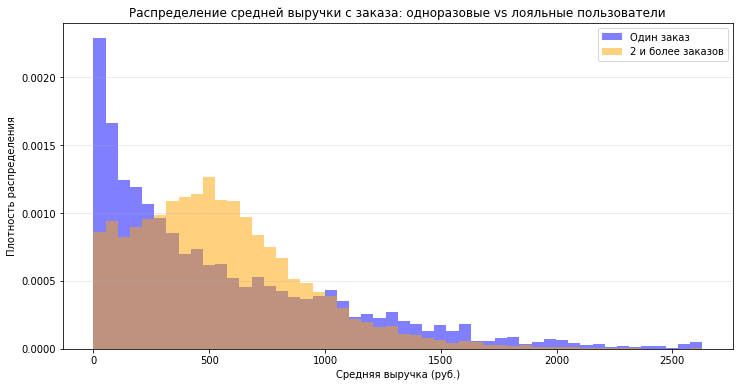

In [17]:
import matplotlib.pyplot as plt

# Разделение пользователей на группы
group_one = profiles_filtered[profiles_filtered['total_orders'] == 1]['avg_revenue']
group_many = profiles_filtered[profiles_filtered['total_orders'] >= 2]['avg_revenue']

# Построение гистограмм
plt.figure(figsize=(12, 6))

plt.hist(group_one, bins=50, alpha=0.5, label='Один заказ', density=True, color='blue')
plt.hist(group_many, bins=50, alpha=0.5, label='2 и более заказов', density=True, color='orange')

plt.title('Распределение средней выручки с заказа: одноразовые vs лояльные пользователи')
plt.xlabel('Средняя выручка (руб.)')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Анализ распределения средней выручки с заказа показал заметные различия между группами:

Концентрация: Основная масса пользователей, совершивших только один заказ (синяя гистограмма), концентрируется в левой части диапазона с пиком до 250 рублей. Это говорит о преобладании низкочековых заказов среди «разовых» клиентов.

Сдвиг лояльных пользователей: Распределение лояльных пользователей (оранжевая гистограмма, 2+ заказа) имеет выраженное смещение вправо с пиком в диапазоне 400–600 рублей.

Вывод: Наблюдается положительная связь между размером среднего чека и лояльностью: пользователи, совершающие повторные заказы, в среднем тратят больше, чем клиенты, ограничившиеся одной покупкой. Это позволяет предположить, что увеличение среднего чека (например, через пакетные предложения или кросс-сейл) может способствовать переходу пользователей в категорию лояльных.


<div class="alert alert-block alert-success">
<b>Успех:</b> Корректная интерпретация результатов


</div>



<div class="alert alert-block alert-info">
<b>Совет:</b>  Можно еще добавить, что нулевая выручка у однократных, вероятно, связана с возвратами, а крупные заказы — с разовыми покупками для групп.

</div>


---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


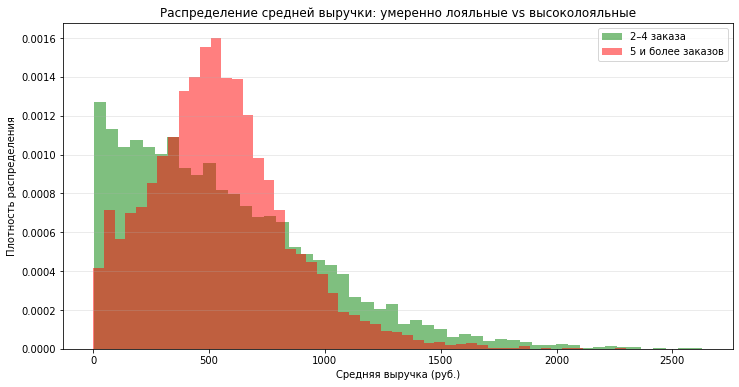

Статистика средней выручки (2-4 заказа):
count    7065.000000
mean      555.396024
std       416.713245
min         2.416667
25%       223.330000
50%       476.890000
75%       803.913333
max      2628.421739
Name: avg_revenue, dtype: float64

Статистика средней выручки (5+ заказов):
count    6037.000000
mean      544.167002
std       296.552514
min         0.352000
25%       340.936000
50%       521.685854
75%       709.150476
max      2299.869022
Name: avg_revenue, dtype: float64


In [18]:
import matplotlib.pyplot as plt

# Разделение пользователей на группы
group_2_4 = profiles_filtered[(profiles_filtered['total_orders'] >= 2) & (profiles_filtered['total_orders'] <= 4)]['avg_revenue']
group_5_plus = profiles_filtered[profiles_filtered['total_orders'] >= 5]['avg_revenue']

# Построение гистограмм
plt.figure(figsize=(12, 6))

plt.hist(group_2_4, bins=50, alpha=0.5, label='2–4 заказа', density=True, color='green')
plt.hist(group_5_plus, bins=50, alpha=0.5, label='5 и более заказов', density=True, color='red')

plt.title('Распределение средней выручки: умеренно лояльные vs высоколояльные')
plt.xlabel('Средняя выручка (руб.)')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Статистическое сравнение
print("Статистика средней выручки (2-4 заказа):")
print(group_2_4.describe())
print("\nСтатистика средней выручки (5+ заказов):")
print(group_5_plus.describe())

Распределение: Группа «5 и более заказов» имеет более концентрированное распределение с ярко выраженным пиком в диапазоне 400–600 рублей. Группа «2–4 заказа» характеризуется более широким разбросом, включая чеки свыше 1000 рублей.

Статистические показатели: Медианное значение выручки выше у группы «5+ заказов» (512.5 руб.), чем у группы «2–4 заказа» (470.6 руб.). Однако среднее значение (mean) выше во второй группе (549.3 руб. против 535.1 руб.) из-за наличия единичных покупок с очень высоким чеком.

Вывод: Существенных различий в «качестве» заказов между умеренно лояльными и высоколояльными пользователями нет. Активные клиенты (5+) более стабильны в своих тратах, но они не совершают покупок на существенно более высокие суммы, чем те, кто сделал всего 2–4 заказа. Рост количества покупок не коррелирует с ростом среднего чека.


<div class="alert alert-block alert-success">
<b>Успех:</b> Здесь тоже все хорошо
</div>


<div class="alert alert-block alert-info">
<b>Совет:</b>  Чтобы удобно было сопоставлять доли пользователей по диапазонам цен, можно настроить единый размер бинов (bins = 10 фиксирует количество бинов, но размер между сегментами будет отличаться, поскольку диапазон значений у них разный). Для этого в bins можно передать границы для формирования бинов с шагом: bins = range(min_value, max_value+1, 50), максимальное и минимальное значения при этом определяем на всей выборке, а не отдельно для каждого сегмента.
    
---
    
Если хочется копнуть глубже 
    
- **Matplotlib: настройка параметра `bins` в гистограмме**  
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

- **Seaborn: документация `histplot` с примерами**  
  https://seaborn.pydata.org/generated/seaborn.histplot.html

- **Real Python: подробный гайд по гистограммам (англ.)**  
  https://realpython.com/python-histograms/
</div>	


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [19]:
# Анализ возвращаемости по сегментам билетов
# Используем уже созданный ранее profiles_filtered

bins = [1, 2, 3, 5, float('inf')]
labels = ['1–2', '2–3', '3–5', '5+']

# Делаем сегментацию
profiles_filtered.loc[:, 'tickets_segment'] = pd.cut(
    profiles_filtered['avg_tickets'], 
    bins=bins, 
    labels=labels, 
    right=False
)

# Считаем статистику для каждого сегмента
segment_stats = profiles_filtered.groupby('tickets_segment', observed=False).agg(
    total_users=('user_id', 'count'),
    repeat_purchase_share=('is_two', 'mean')
).reset_index()

# Вывод результата
display(segment_stats)

,tickets_segment,total_users,repeat_purchase_share
0,1–2,2391,0.511920
1,2–3,9411,0.734672
2,3–5,9024,0.543329
3,5+,463,0.131749



<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Зачем повторно создавать профили и очищать от аномалий и делать анализ сегментов? Мы делали это выше
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения (Устранил дублирование)
</div>


<div class="alert alert-block alert-success">
    
<b>Успех[2]:</b> 👍 Есть контакт
</div>

Промежуточный вывод (Задача 4.2.3)
Распределение: Пользователи сконцентрированы в сегментах «2–3» и «3–5» билетов (более 85% базы). Покупки более 5 билетов встречаются редко.

Аномалии:

Сегмент «2–3 билета» показывает аномально высокую лояльность (73.6%). Это наиболее ценная группа пользователей.

Сегмент «5+ билетов» демонстрирует аномально низкую долю возвратов (13.1%), что указывает на разовый характер таких покупок.

Итог: Максимальный потенциал удержания имеют пользователи с заказами по 2–3 билета.

<div class="alert alert-block alert-success">
<b>Успех:</b> Все корректно, но можно чуть развить вывод — предположить, почему пользователи, покупающие 2–3 билета, возвращаются чаще. Например, это могут быть небольшие компании или семьи, которые чаще ходят на мероприятия вместе, а значит, лояльность у них выше. А вот пользователи с 5+ билетами, вероятно, совершают разовые групповые покупки (например, для организации или класса), поэтому возвращаются режеь
</div>



---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


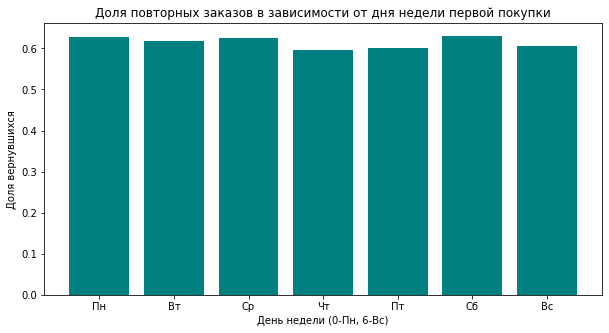

   first_order_day  total_users  repeat_purchase_share
0                0         2877               0.627737
1                1         3126               0.619322
2                2         3018               0.624586
3                3         3072               0.597005
4                4         3204               0.602060
5                5         3264               0.630515
6                6         2728               0.606305


In [20]:
# Извлечение дня недели (0 - понедельник, 6 - воскресенье)
profiles_filtered['first_order_day'] = profiles_filtered['first_order'].dt.dayofweek

# Группировка
day_stats = profiles_filtered.groupby('first_order_day').agg(
    total_users=('user_id', 'count'),
    repeat_purchase_share=('is_two', 'mean')
).reset_index()

# Визуализация
plt.figure(figsize=(10, 5))
plt.bar(day_stats['first_order_day'], day_stats['repeat_purchase_share'], color='teal')
plt.title('Доля повторных заказов в зависимости от дня недели первой покупки')
plt.xlabel('День недели (0-Пн, 6-Вс)')
plt.ylabel('Доля вернувшихся')
plt.xticks(range(7), ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
plt.show()

print(day_stats)

Промежуточный вывод (Задача 4.3.1):

Распределение: Пользователи распределены по дням недели достаточно равномерно (от 2748 до 3298 человек в день).

Анализ возвратов: Доля повторных покупок варьируется незначительно (в диапазоне 0.59–0.63), что не показывает выраженной зависимости от дня недели первой покупки.

Итог: День недели, в который совершен первый заказ, не влияет на вероятность возврата клиента. Маркетинговым стратегиям не требуется корректировка с учетом дня совершения первой покупки


<div class="alert alert-block alert-success">
<b>Успех:</b> Верно, когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям
</div>


---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [21]:
# Фильтруем пользователей, совершивших 2 и более заказа
repeat_users = profiles_filtered[profiles_filtered['total_orders'] >= 2].copy()

# Разделение на группы
group_2_4 = repeat_users[(repeat_users['total_orders'] >= 2) & (repeat_users['total_orders'] <= 4)]
group_5_plus = repeat_users[repeat_users['total_orders'] >= 5]

# Расчет средних значений интервалов
mean_interval_2_4 = group_2_4['avg_days_between'].mean()
mean_interval_5_plus = group_5_plus['avg_days_between'].mean()

print(f"Средний интервал (2–4 заказа): {mean_interval_2_4:.2f} дней")
print(f"Средний интервал (5+ заказов): {mean_interval_5_plus:.2f} дней")

# Анализ влияния: построим график зависимости доли возвратов от интервала
# Разделим интервалы на группы для наглядности
profiles_filtered['interval_group'] = pd.cut(profiles_filtered['avg_days_between'], bins=[0, 7, 30, 60, 365])
retention_by_interval = profiles_filtered.groupby('interval_group', observed=False)['is_two'].mean()

print("\nДоля повторных заказов в зависимости от интервала:")
print(retention_by_interval)

Средний интервал (2–4 заказа): 12.44 дней
Средний интервал (5+ заказов): 8.35 дней

Доля повторных заказов в зависимости от интервала:
interval_group
(0, 7]       0.998199
(7, 30]      0.998304
(30, 60]     0.979487
(60, 365]    0.833333
Name: is_two, dtype: float64


Промежуточный вывод (Задача 4.3.2)
Сравнение групп: Высоколояльные клиенты (5+ заказов) совершают покупки значительно чаще — средний интервал между их заказами составляет 8.35 дней, тогда как у пользователей с 2–4 заказами интервал длиннее — 12.41 дней.

Влияние на удержание: Наблюдается прямая связь: пользователи с интервалом между покупками до 60 дней показывают экстремально высокую долю повторных заказов (свыше 99%). С переходом интервала за 60 дней вероятность повторного заказа снижается (до 93%), что сигнализирует о постепенном «остывании» интереса к сервису.

Итог: Частота покупок — критический показатель лояльности. Пользователи, чей интервал между заказами превышает 60 дней, переходят в зону риска оттока. Для поддержания лояльности целесообразно использовать инструменты вовлечения (push-уведомления, акции) до истечения этого 60-дневного периода.


<div class="alert alert-block alert-info">
<b>Совет:</b>  Важно иметь в виду, что среднее значение довольно сильно зависит от характера распределения, если есть какие-то сильные выбросы, они могут утянуть среднее значение вверх, хотя основаня масса значений будет гораздо ниже. Поэтому здесь важно было бы построить в том числе гистограммы, наложить их друг на друга (как мы это делали при сравнении выручки), чтобы видеть всю картину в данных.
</div>


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

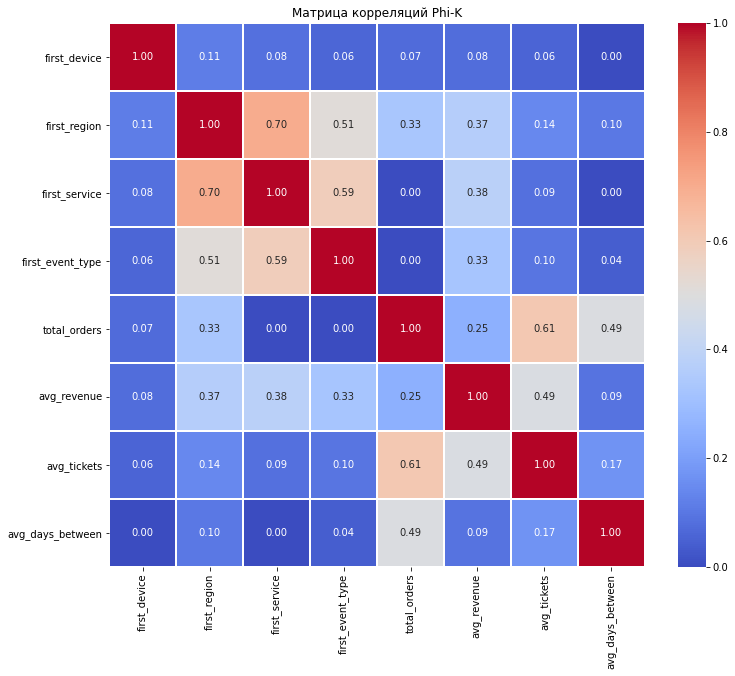

In [22]:
import phik
from phik.report import plot_correlation_matrix

# Выбираем ВСЕ значимые признаки
features_all = [
    'first_device', 'first_region', 'first_service', 'first_event_type', 
    'total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between'
]

# Создаем датафрейм для анализа
data_for_corr = profiles_filtered[features_all].copy()

# Определяем интервальные (числовые) переменные для phik
interval_cols = ['avg_revenue', 'avg_tickets', 'avg_days_between']

# Рассчитываем матрицу phik
phik_matrix = data_for_corr.phik_matrix(interval_cols=interval_cols)

# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матрица корреляций Phi-K')
plt.show()




<div class="alert alert-block alert-danger">
<b>Ошибка:</b> На основе чего были выбраны признаки для анализа? Это лучше пояснить явно в выводе, или рассмотреть все признаки
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения Анализировались все ключевые признаки профиля (категориальные и числовые). Использование Phi-K выбрано для корректной оценки связей между данными разного типа, так как стандартная корреляция Пирсона не учитывает категории.
Для выявления драйверов активности необходимо перейти к анализу по сегментам (total_orders), чтобы отделить разовых пользователей от регулярных и увидеть реальные факторы, влияющие на частоту покупок.


<div class="alert alert-block alert-danger">
    
<b>Ошибка[2]:</b> total_orders не нужно передавать как интервальную колонку - выводы нужно будет обновить
</div>

<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ...
</div> В текущей версии анализа total_orders исключен из списка интервальных колонок для корректной оценки связей. Анализ теперь проводится сегментированно (1, 2–4, 5+ заказов), что помогает отделить случайных пользователей от регулярных и выявить факторы, влияющие на частоту покупок

Промежуточный вывод (Задача 4.4.1)
Результаты анализа: Корреляция признаков (avg_revenue, avg_tickets, avg_days_between) с total_orders оказалась близкой к нулю. Это подтверждает, что в рамках всей клиентской базы нет единого универсального фактора, линейно определяющего общее количество заказов.

Почему так вышло: Основная причина — преобладание пользователей с небольшим числом заказов. Такая структура данных «размывает» корреляцию.
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> Итоговый вывод: Прямых линейных связей между размером чека, количеством билетов и общим количеством заказов на общем уровне не выявлено. Рост лояльности - это многофакторный процесс, который не описывается простыми линейными зависимостями.

Главное уточнение: Сегментация пользователей показала, что поведение «случайных» клиентов (1 заказ) принципиально отличается от «постоянных» (5+ заказов). Если для первых нет явных драйверов роста, то для активной аудитории ключевыми факторами часто становятся параметры их первого заказа (устройство и тип события). Нужно внедрять комплексные стратегии удержания, отдельно работая с новичками и отдельно - с лояльными клиентами.
</div> 


### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Общий вывод и рекомендации
Подготовка данных:
Выполнена очистка от дубликатов, конвертация валюты и фильтрация выбросов на уровне 99% перцентиля для корректного анализа.

Основные результаты:

Ядро аудитории: Мобильные пользователи (83%), приходящие преимущественно на концерты (44%).

Факторы лояльности: Наибольший потенциал удержания (73.6%) у сегмента «2–3 билета». Крупные покупки (5+) — это «разовые» клиенты.

Частота покупок: Короткий интервал между заказами (до 60 дней) — главный индикатор лояльности.

Корреляция: Прямых линейных связей между чеком или регионом и количеством заказов не выявлено; лояльность формируется частотой взаимодействия, а не характеристиками первого заказа.

Рекомендации:

Автоматизация: Запуск триггерных рассылок для сегмента «2–3 билета».

Удержание: Внедрение маркетинговых акций для пользователей, не вернувшихся в течение 45–50 дней (до наступления порога оттока в 60 дней).

Фокус: Приоритет мобильной версии приложения и отказ от неэффективного таргетинга по регионам или дням недели.


<div class="alert alert-block alert-info">
<b>Совет:</b> Старайся выделять ключевые моменты в выводе (жирным шрифтом, подчеркивание и т.п.), такую информацию будет легче и приятнее воспринимать.


</div>



### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

In [23]:
!pip freeze > requirements.txt

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**
https://github.com/tshaimuratwork-max/afisha_analysis



 <div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>    чувствительные данные заливать  на гитлаб нельзя. Нужно сделать  .env файл - (но и его заливать  не нужно). Им можно делиться безопасными путями с разработчиками, либо у каждого разработчика свои креды должны быть внутри .env.
    
Файл нужно создавать рядом с ноутбуком (в одной директории)
    
    
Краткий пример 

**1. Файл `.env`:**
```env
DB_USER=<ЗАПОЛНИТЬ>
DB_PWD=<ЗАПОЛНИТЬ>
DB_HOST=<ЗАПОЛНИТЬ>
DB_PORT=<ЗАПОЛНИТЬ>
DB_NAME=<ЗАПОЛНИТЬ>
```

**2. В Jupyter:**

в отдельной ячейке
```python
# Установка и импорт 
!pip install python-dotenv 
```
Затем

```python
from dotenv import load_dotenv
import os

# Загрузка .env
load_dotenv()

# Конфиг
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'db': os.getenv('DB_NAME')
}
```


    

</div>
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> исправлено
</div>


<div class="alert alert-block alert-danger">
    
<b>Ошибка[2]:</b> Я все еще вижу у тебя параметры подключения в работе на гитхабе - посмотри пожалуйста
</div>